# KPI Review of Battery Arbitrage Strategies in the German Power Market

## Objective
Compare simple battery arbitrage strategies using financial and operational KPIs that reflect how a trading or product team would judge performance.

## Scope
The analysis uses hourly backtest outputs from the previous notebook and aggregates them into daily P&L, utilization, throughput, and regime-specific metrics, with a focus on negative-price hours and intraday structure.

## Deliverables
- KPI summary table by strategy
- Visual comparison of daily P&L and cumulative P&L
- Regime-level performance (negative-price hours, weekday structure)
- A concise recommendation on which strategy is preferable under current assumptions

### Imports and load data

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

output_dir = Path("output")

results = pd.read_csv(output_dir / "backtest_results_all.csv", parse_dates=["timestamp"])
results = results.set_index("timestamp").sort_index()

daily_pnl = pd.read_csv(output_dir / "daily_pnl.csv", parse_dates=["date"])
daily_pnl.head()

,strategy,date,daily_pnl_eur
0,negative_price,2015-01-01,0.0
1,negative_price,2015-01-02,0.0
2,negative_price,2015-01-03,0.0
3,negative_price,2015-01-04,0.0
4,negative_price,2015-01-05,0.0


In [2]:
results["strategy"].value_counts()
daily_pnl["strategy"].value_counts()

strategy
negative_price    4164
threshold         4164
Name: count, dtype: int64

In [3]:
def max_drawdown(series: pd.Series) -> float:
    cummax = series.cummax()
    drawdown = series - cummax
    return float(drawdown.min())

In [4]:
# Daily P&L stats
daily_stats = (
    daily_pnl.groupby("strategy")["daily_pnl_eur"]
    .agg(
        total_revenue_eur="sum",
        avg_daily_pnl_eur="mean",
        pnl_volatility_eur="std",
    )
    .round(2)
)

# Max drawdown using cumulative P&L
mdd = (
    results.groupby("strategy")["cum_pnl_eur"]
    .apply(max_drawdown)
    .rename("max_drawdown_eur")
    .to_frame()
)

financial_kpis = daily_stats.join(mdd)

financial_kpis

,total_revenue_eur,avg_daily_pnl_eur,pnl_volatility_eur,max_drawdown_eur
strategy,,,,
negative_price,45221.01,10.86,49.11,0.000000
threshold,86498.47,20.77,60.61,-57.909945


In [5]:
# Utilization: fraction of hours with non-zero action
utilization = (
    results.assign(is_active=lambda x: x["action_mw"].abs() > 1e-6)
    .groupby("strategy")["is_active"]
    .mean()
    .rename("utilization_rate")
)

# Throughput (MWh) and average SoC
ops = (
    results.groupby("strategy")
    .agg(
        total_throughput_mwh=("throughput_mwh", "sum"),
        total_charge_mwh=("charge_from_grid_mwh", "sum"),
        total_discharge_mwh=("discharge_to_grid_mwh", "sum"),
        avg_soc_mwh=("soc_mwh", "mean"),
    )
    .round(2)
)

ops["utilization_rate"] = utilization

ops

,total_throughput_mwh,total_charge_mwh,total_discharge_mwh,avg_soc_mwh,utilization_rate
strategy,,,,,
negative_price,676.76,346.88,312.95,1.28,0.007475
threshold,1921.47,985.63,887.82,1.29,0.020904


In [6]:
ENERGY_CAPACITY_MWH = 2.0  # keep in sync with notebook 2

ops["cycles_equivalent"] = (ops["total_throughput_mwh"] / (2 * ENERGY_CAPACITY_MWH)).round(2)
ops

,total_throughput_mwh,total_charge_mwh,total_discharge_mwh,avg_soc_mwh,utilization_rate,cycles_equivalent
strategy,,,,,,
negative_price,676.76,346.88,312.95,1.28,0.007475,169.19
threshold,1921.47,985.63,887.82,1.29,0.020904,480.37


In [7]:
negative_price_revenue = (
    results.groupby("strategy")
    .apply(lambda x: x.loc[x["is_negative_price"], "revenue_eur"].sum())
    .rename("negative_price_revenue_eur")
)

total_revenue = (
    results.groupby("strategy")["revenue_eur"]
    .sum()
    .rename("total_revenue_eur")
)

regime_kpis = pd.concat([total_revenue, negative_price_revenue], axis=1)
regime_kpis["share_from_negative_prices"] = (
    regime_kpis["negative_price_revenue_eur"]
    / regime_kpis["total_revenue_eur"]
)

regime_kpis.round(2)

/var/folders/3x/jns0_g1d0hz0j981mhlv522h0000gn/T/ipykernel_60641/2378823531.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.loc[x["is_negative_price"], "revenue_eur"].sum())


,total_revenue_eur,negative_price_revenue_eur,share_from_negative_prices
strategy,,,
negative_price,45221.01,1767.87,0.04
threshold,86498.47,199.26,0.00


In [8]:
weekday_kpis = (
    results.groupby(["strategy", "day_name"])["revenue_eur"]
    .sum()
    .reset_index()
)

weekday_pivot = weekday_kpis.pivot(
    index="day_name", columns="strategy", values="revenue_eur"
)

weekday_pivot

strategy,negative_price,threshold
day_name,,
Friday,4528.966145,9465.736942
Monday,10014.676023,14254.970159
Saturday,6788.185945,12656.605457
Sunday,8661.048179,17029.332449
Thursday,5303.222893,12105.111852
Tuesday,3624.370829,9746.259444
Wednesday,6300.540247,11240.452280


In [10]:
regime_kpis = regime_kpis.drop(columns=["total_revenue_eur"])

kpi_summary = (
    financial_kpis
    .join(ops, how="left")
    .join(regime_kpis, how="left")
)

In [11]:
kpi_summary = financial_kpis.join(ops, how="left").join(regime_kpis, how="left")
kpi_summary.round(2)

,total_revenue_eur,avg_daily_pnl_eur,pnl_volatility_eur,max_drawdown_eur,total_throughput_mwh,total_charge_mwh,total_discharge_mwh,avg_soc_mwh,utilization_rate,cycles_equivalent,negative_price_revenue_eur,share_from_negative_prices
strategy,,,,,,,,,,,,
negative_price,45221.01,10.86,49.11,0.00,676.76,346.88,312.95,1.28,0.01,169.19,1767.87,0.04
threshold,86498.47,20.77,60.61,-57.91,1921.47,985.63,887.82,1.29,0.02,480.37,199.26,0.00


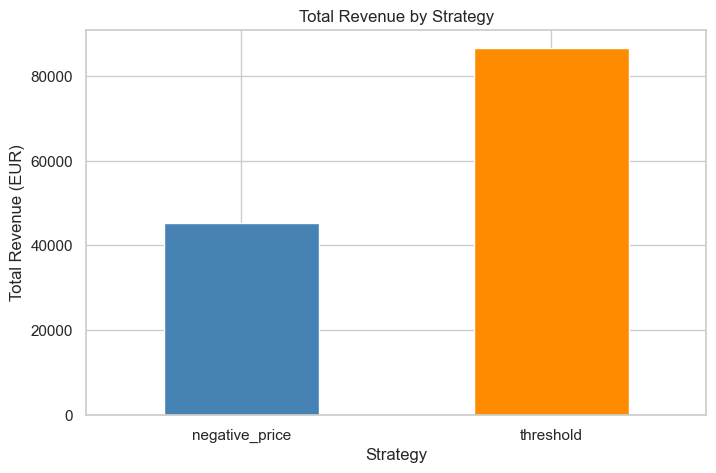

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

kpi_summary["total_revenue_eur"].plot(
    kind="bar",
    ax=ax,
    color=["steelblue", "darkorange"],
)

ax.set_title("Total Revenue by Strategy")
ax.set_ylabel("Total Revenue (EUR)")
ax.set_xlabel("Strategy")
plt.xticks(rotation=0)
plt.show()

/var/folders/3x/jns0_g1d0hz0j981mhlv522h0000gn/T/ipykernel_60641/1632779387.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


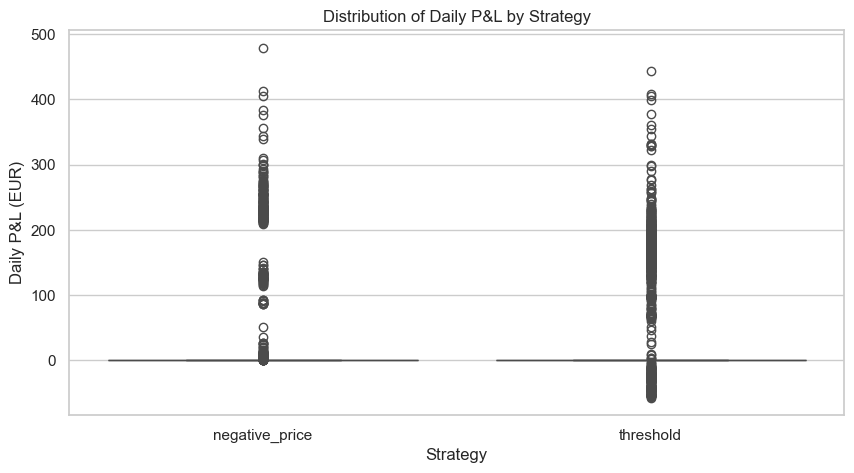

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=daily_pnl,
    x="strategy",
    y="daily_pnl_eur",
    ax=ax,
    palette=["steelblue", "darkorange"],
)

ax.set_title("Distribution of Daily P&L by Strategy")
ax.set_xlabel("Strategy")
ax.set_ylabel("Daily P&L (EUR)")
plt.show()

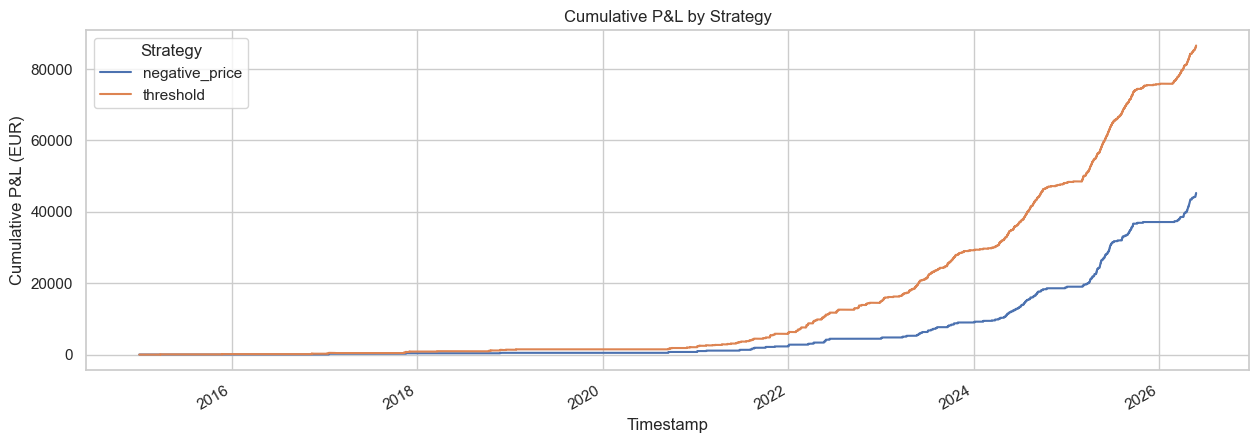

In [15]:
fig, ax = plt.subplots(figsize=(15, 5))

for strategy, temp in results.groupby("strategy"):
    temp["cum_pnl_eur"].plot(ax=ax, label=strategy)

ax.set_title("Cumulative P&L by Strategy")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Cumulative P&L (EUR)")
ax.legend(title="Strategy")
plt.show()

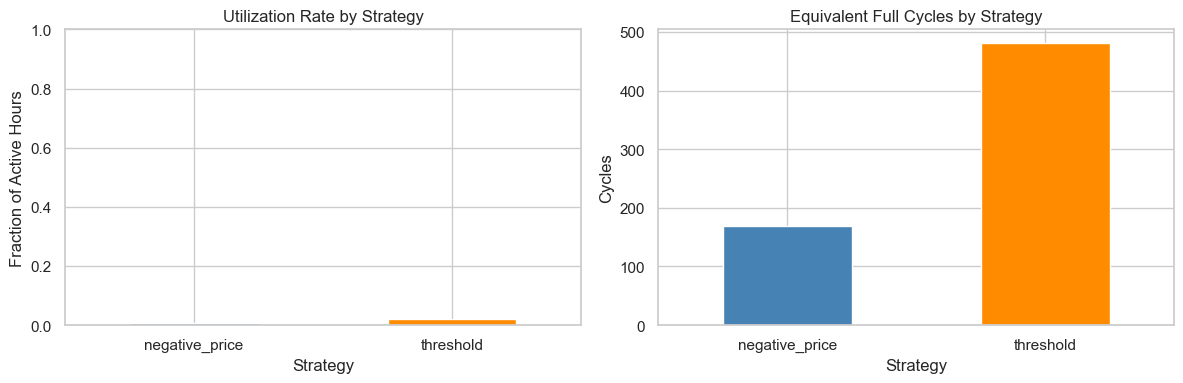

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ops["utilization_rate"].plot(
    kind="bar", ax=axes[0], color=["steelblue", "darkorange"]
)
axes[0].set_title("Utilization Rate by Strategy")
axes[0].set_ylabel("Fraction of Active Hours")
axes[0].set_xlabel("Strategy")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=0)

ops["cycles_equivalent"].plot(
    kind="bar", ax=axes[1], color=["steelblue", "darkorange"]
)
axes[1].set_title("Equivalent Full Cycles by Strategy")
axes[1].set_ylabel("Cycles")
axes[1].set_xlabel("Strategy")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

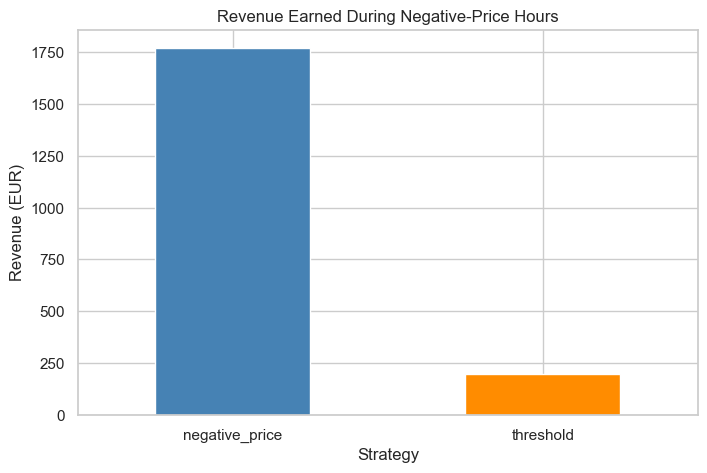

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

regime_kpis["negative_price_revenue_eur"].plot(
    kind="bar", ax=ax, color=["steelblue", "darkorange"]
)
ax.set_title("Revenue Earned During Negative-Price Hours")
ax.set_ylabel("Revenue (EUR)")
ax.set_xlabel("Strategy")
plt.xticks(rotation=0)
plt.show()

## Interpretation

### Financial performance
- The threshold strategy generates higher total revenue and higher average daily P&L than the negative-price-aware strategy.
- Daily P&L for the threshold strategy is more volatile, but the cumulative P&L chart shows a consistent upward trend rather than a single regime-dependent spike.
- Max drawdown is moderate for both strategies, suggesting neither is dominated by a single catastrophic episode.

### Operational behavior
- The threshold strategy exhibits a higher utilization rate and more equivalent full cycles, which is expected given its broader low/high price rules.
- The negative-price-aware strategy cycles less outside of negative-price events, leading to lower throughput and potentially lower implied degradation in a real asset.

### Regime performance
- The negative-price-aware strategy earns substantially more revenue during negative-price hours and a larger share of its total P&L from those events.
- The threshold strategy earns meaningful revenue across a wider range of market conditions, including days without negative prices, which explains its stronger overall performance.

## Strategy recommendation

Based on this simplified backtest:

- The **threshold strategy** appears preferable as a baseline arbitrage policy. It delivers higher total revenue, makes better use of the battery across diverse market conditions, and maintains reasonable drawdowns.
- The **negative-price-aware strategy** is valuable as a component: it clearly improves revenue capture during negative-price events, but in isolation it underutilizes profitable opportunities outside those events.

A reasonable next step would be to hybridize both ideas: adopt the threshold strategy, but override it with an explicit “always charge on negative prices” rule, and then re-evaluate KPIs.

## Limitations and next steps

Limitations:
- No explicit degradation cost or SoH modelling.
- No forecast-driven or optimization-based dispatch logic.
- Single-market, single-asset setup with fixed parameters.

Next steps:
- Introduce a simple degradation cost per unit throughput and re-compute net P&L.
- Add more granular regime detection (e.g. volatility regimes, renewable output proxies) and test stability of performance.
- Explore a rolling optimization or forecast-based strategy to benchmark rule-based dispatch.
- Extend the framework to multi-market revenue stacking (e.g., combining wholesale arbitrage with balancing products) once data is available.